In [1]:
import os
import pandas as pd
import numpy as np
import scipy

import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib import rc
import seaborn as sns
import Bio.PDB
from scipy import stats
from Bio.PDB import SASA # SASA module won't load from newest version of Biopython for some reason
# import Geometry # Biopython Geometry module still not on main branch

import time
import sys
import glob
sys.path.append('/data/mhoffert/fiererlab/adenylate_kinase_ogt/protein_utils/')

import Geometry

## Loading data and structures

In [2]:
write_processed_pdbs = False

In [5]:
# # Import enrichment data

# ogt_data_filename = "genome2temp.csv"
# rosetta_data_filename = 'rosetta_out.sc'

# struct_dir = "finalized_models"

# dir to output figures
# output_dir = 'out_closed_means'

# if not os.path.isdir(output_dir):
#     os.mkdir(output_dir)

# ogt_df = pd.read_csv(ogt_data_filename)
# rosetta_df = pd.read_csv(rosetta_data_filename, delim_whitespace=True, skiprows=1, index_col='description')

In [6]:
rosetta_data_filename = '/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/rosetta_out.sc'

In [7]:
rosetta_df = pd.read_csv(rosetta_data_filename, delim_whitespace=True, skiprows=1, index_col='description')

In [14]:
# make ogt df
files = glob.glob('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/test_structures/*.pdb')

In [25]:
ogt_df = pd.Series(index=['_'.join(f.split('/')[-1].split('_adk')[0].split('_')[-3:]) for f in files],
          data=[float(f.split('/')[-1].split('adk_temp_')[-1].split('_bitscore')[0]) for f in files]).reset_index()
ogt_df = ogt_df.rename(columns={'index':'genome', 0:'temp'})

In [26]:
for f in files:
    genome = '_'.join(f.split('/')[-1].split('_adk')[0].split('_')[-3:])
    os.system(f'mv {f} /data/mhoffert/fiererlab/adenylate_kinase_ogt/data/test_structures/{genome}_closed.pdb')

In [28]:
ogt_df.to_csv('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/genome2temp.csv')

In [29]:
struct_dir = '/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/test_structures/'

In [30]:
pdb_files = set()
struct_path = os.path.join(os.getcwd(), struct_dir)
with os.scandir(struct_path) as d:
    for entry in d:
        if entry.name.endswith('.pdb') and entry.is_file():
            pdb_files.add(entry.name)

pdbs_dict = {}
for genome in ogt_df['genome']:
    pdbs_dict[genome] = []
    if genome + '_closed.pdb' in pdb_files:
        pdbs_dict[genome].append(genome + '_closed.pdb')
        if genome + '_open.pdb' in pdb_files:
            pdbs_dict[genome].append(genome + '_open.pdb')

In [32]:
# Prep settings for making plots
sns.set(font="Arial")
sns.set(font_scale=1.5)
sns.set_style('ticks')

In [34]:
from IPython.display import display, clear_output

In [36]:
# get structures and read them in
structs_dict = {}
parser = Bio.PDB.PDBParser()
count = 0
for genome, struct_names in pdbs_dict.items():
    if count % 10 == 0:
        display(count)
        clear_output(wait=True)
    for struct_name in struct_names:
        if struct_name.endswith('closed.pdb'):
            structs_dict[genome] = [parser.get_structure(struct_name.replace('.pdb',''), 
                                                              os.path.join(struct_path, struct_name))]
    count += 1

5220

## Calculating residue-level metrics and processing structures

In [39]:
# Calculate a bunch of residue-level metrics

df_collector = []

t1 = time.perf_counter()

io=Bio.PDB.PDBIO()
count = 0
for genome, structs in structs_dict.items():

    # if count % 10 == 0:
    display(count)
    clear_output(wait=True)

    struct = structs[0]
    temp_df = pd.DataFrame()
    
    # remove hydrogens
    #for atom in Bio.PDB.Selection.unfold_entities(struct, 'A'):
        #if atom.get_name()[0] == 'H':
            #Bio.PDB.Selection.unfold_entities(atom, 'R')[0].__delitem__(atom.id)
    
    queryable_protein = []
    for res in Bio.PDB.Selection.unfold_entities(struct, 'R'):
        if Bio.PDB.Polypeptide.is_aa(res, standard=True):
            queryable_protein.append(res)
    
    # iteratively remove residues at the termini with low pLDDT
    res_to_remove = []
    counter = 0
    res = queryable_protein[counter]
    while res['CA'].get_bfactor() < 70 and counter < 30:
        res_to_remove.append(res)
        counter += 1
        res = queryable_protein[counter]
        
    counter = 1
    res = queryable_protein[-counter]
    while res['CA'].get_bfactor() < 70 and counter < 30:
        res_to_remove.append(res)
        counter += 1
        res = queryable_protein[-counter]
        
    for res in res_to_remove:
        #struct[0]['A'].__delitem__(res.id)
        Bio.PDB.Selection.unfold_entities(res, 'C')[0].__delitem__(res.id)
    
    queryable_protein = []
    for res in Bio.PDB.Selection.unfold_entities(struct, 'R'):
        if Bio.PDB.Polypeptide.is_aa(res, standard=True):
            queryable_protein.append(res)
    
    # identify residues that are present, should be present, are not present, and are adjacent to residues that are not present
    # useful to avoid errors when running code that doesn't like missing residues or neighbors
    # not necessary for AF models but if we want to compare AF structures to crystal structures at any point it'll be handy
    residues_present = sorted([res.id[1] for res in queryable_protein])
    residues_range = list(range(residues_present[0], residues_present[-1] + 1))
    residues_absent = set(residues_range).difference(residues_present)
    residues_missing_nbrs = residues_absent.union({residues_range[0],residues_range[-1]},{resi+1 for resi in residues_absent},{resi-1 for resi in residues_absent})
    
    # set residue positions as indices for df
    temp_df['Position'] = residues_range
    temp_df = temp_df.set_index('Position')
    
    for chain in Bio.PDB.Selection.unfold_entities(list(queryable_protein), 'C'):
        if chain.id == 'A':
            temp_df = temp_df.copy()
            temp_df['Position'] = temp_df.index
            #temp_df['chain'] = chain.id

            # calculate contact density
            contact_cutoffs = [4.5]
            nbr_search = Bio.PDB.NeighborSearch(Bio.PDB.Selection.unfold_entities(chain, 'A'), bucket_size=1000)
            for cutoff in contact_cutoffs:
                contacts = nbr_search.search_all(cutoff, 'R')
                contact_count_dict = {resi: 0 if resi not in residues_absent else np.NaN for resi in temp_df['Position']}
                for (res1, res2) in contacts:
                    contact_count_dict[res1.id[1]] += 1
                    contact_count_dict[res2.id[1]] += 1
                temp_df[f'Contacts at {cutoff} Å'] = temp_df['Position'].map(contact_count_dict)

            # solvent exposure - Shrake-Rupley algorithm ("rolling ball" method)
            sr = SASA.ShrakeRupley(probe_radius=1.40, n_points=1000)
            sr.compute(struct[0], level="R") # note that this omits burial due to bound ligands or contacts with other chains    
            temp_df['SASA'] = temp_df['Position'].map(lambda pos: chain[pos].sasa if not pos in residues_absent else np.NaN)
            
            temp_df_m = temp_df.mean(numeric_only=True)
                        
            temp_df_m['genome'] = genome
            df_collector.append(temp_df_m)
            
            # save files with trimmed termini for analysis with rosetta
            if write_processed_pdbs:
                if not os.path.isdir('processed_structs'):
                    os.mkdir('processed_structs')
                    
                # remove hydrogens?
                if False:
                    for atom in Bio.PDB.Selection.unfold_entities(struct, 'A'):
                        if atom.get_name()[0] == 'H':
                            Bio.PDB.Selection.unfold_entities(atom, 'R')[0].__delitem__(atom.id)
                filename = struct.id + '_' + chain.id + '_processed' + '.pdb'
                io.set_structure(struct)
                io.save(os.path.join('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/processed_structures', filename))

    count += 1
            
t2 = time.perf_counter()
print('Time elapsed:', t2-t1)

Time elapsed: 48473.015765163116


## Arranging data for plotting

In [40]:
metrics_df = pd.concat(df_collector, axis=1)
metrics_df = metrics_df.T
metrics_df = metrics_df.merge(ogt_df,on='genome')
metrics_df.head(5)

,Position,Contacts at 4.5 Å,SASA,genome,temp
0,108.0,11.125581,49.46404,GB_GCA_000016765.1,30.0
1,119.5,11.28972,49.538232,GB_GCA_000242235.1,37.0
2,105.5,11.27619,50.01808,GB_GCA_000283575.1,30.0
3,94.0,11.358289,52.616491,GB_GCA_000376885.1,37.0
4,105.5,11.391753,51.807945,GB_GCA_000411155.1,37.0


In [41]:
# make sure to save! takes a long time to regenerate
metrics_df.to_csv('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/biopdb_metric.tsv', sep='\t')

In [375]:
metrics_df = pd.read_csv('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/biopdb_metric.tsv', sep='\t', index_col=0)
metrics_df.head()

,Position,Contacts at 4.5 Å,SASA,genome,temp
0,108.0,11.125581,49.464040,GB_GCA_000016765.1,30.0
1,119.5,11.289720,49.538232,GB_GCA_000242235.1,37.0
2,105.5,11.276190,50.018080,GB_GCA_000283575.1,30.0
3,94.0,11.358289,52.616491,GB_GCA_000376885.1,37.0
4,105.5,11.391753,51.807945,GB_GCA_000411155.1,37.0


In [376]:
# parse rosetta outputs
rosetta_df = pd.read_csv(rosetta_data_filename, delim_whitespace=True, skiprows=1, index_col='description')
rosetta_df['genome_id'] = ['_'.join(s.split('_adk')[0].split('_closed')[0].split('_')[-3:]) for s in rosetta_df.index] #rosetta_df.index.map(lambda x: x.partition('.')[0])

# make a secondary structure series
secondary_structure = rosetta_df.groupby('genome_id').first()['secondary_structure']

# add rosetta metrics
rosetta_df['%S'] = rosetta_df['secondary_structure'].map(lambda x: x.count('E') / len(x))
rosetta_df['%L'] = rosetta_df['secondary_structure'].map(lambda x: x.count('L') / len(x))
rosetta_df['%H'] = rosetta_df['secondary_structure'].map(lambda x: x.count('H') / len(x))
rosetta_df['length'] = rosetta_df['secondary_structure'].map(len)
rosetta_df['avg_cc_contacts_per_res'] = rosetta_df['total_cc_contacts'] / rosetta_df['length']
rosetta_df = rosetta_df.groupby('genome_id').mean(numeric_only=True)

In [377]:
# rosetta_df['genome'] = rosetta_df.index + '.1'
metrics_df = pd.merge(metrics_df, rosetta_df, left_on='genome', right_index=True)

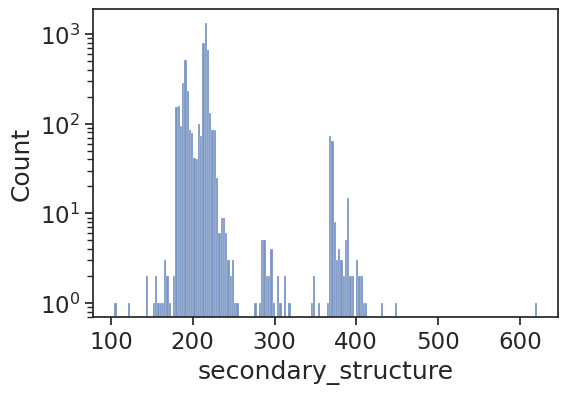

In [378]:
# plot distribution of lengths
fig, ax = plt.subplots(figsize=(6,4))
sns.histplot(secondary_structure.apply(lambda x: len(x))) #, bins=np.logspace(1.9, 3, 50))
# ax.set_xscale('log')
ax.set_yscale('log')

## Structure plotting code

In [159]:
%%javascript
IPython.OutputArea.prototype._should_scroll = function(lines) {
    return false;
}

<IPython.core.display.Javascript object>

In [ ]:
import IPython as IPython

import nglview as nv
import pytraj as pt

In [83]:
from scipy.stats import spearmanr

In [198]:
sys.path.append('/data/mhoffert/fiererlab/adenylate_kinase_ogt/protein_utils/')

In [209]:
from pdb_getter import collapse_and_label

In [359]:
from collections import Counter

In [239]:
# expected structure
# N - A3 - H1 - A5 - H2 - H3 - H4 - A4 - H5 - A2 - H6 - B1 - B2 - C1 - C2 - C3 - H7 - A1 - H8
# C - C  - C  - C  - N  - N  - N  - C  - C  - C  - L  - L  - L  - L  - L  - L  - C  - C  - C

def get_guiding_structures():
    return {
    'E1':'core', 'E2':'core', 'E3':'core', 'E4':'core', 
    'H1':'core', 'H5':'core', 'H7':'core', 'H8':'core', 'H9':'core',
    'H6':'lid', 'B1':'lid', 'B2':'lid','B3':'lid','B4':'lid','B5':'lid',
    'H2':'nmp', 'H3':'nmp', 'H4':'nmp',
    'T1':'ploop','L2':'ploop'
    }
    
def ss_to_domains(ss):
    # transform to list
    structures = [s for s in ss]
    
    # get a dictionary: {'res_start - res_end':'ss_label'}
    # where ss_label = E1 if ss is the first sheet, H4 if ss is the fourth helix, etc.
    struct2res = dict(tuple(k.split(':')[::-1]) for k in collapse_and_label(structures))

    # iterate and make a new list:
    # ['E1', 'E1', 'E1', 'H2', 'H2', 'H2'], etc.
    structure_locs = []
    for key, item in struct2res.items():
        indeces = [int(k) for k in key.split('-')]
        structure_locs += [item] * len(list(range(indeces[0], indeces[1])))

    guiding_structures = get_guiding_structures()
    
    # map E1, etc. to domains in adk
    structure_annot = []
    current='none'
    for item in structure_locs:
        if item in guiding_structures.keys():
            
            current = guiding_structures[item]
    
        structure_annot.append(current)
        
    return struct2res, structure_annot

def draw_adk(pdb, color_ss=[], color_domains=[], ss='', seqfile=None):
    '''
    pdb: filepath to pdb file
    color_ss: cmap of secondary structure colors, if desired
    color_domains: cmap of domain colors, if desired
    ss = string of secondary structures from rosetta
    
    '''
    # load pdb
    traj = pt.load(pdb)
    w = nv.show_pytraj(traj, default_representation=False)
    w.add_cartoon(color='gray')
    
    if len(color_ss) > 0:
        if len(ss) == 0:
            raise ValueError('color_ss=True means ss must be supplied')
        
        colors = nglview_list(color_ss, ss)
        
        scheme = nv.color._ColorScheme(colors, label='secondary structure')
    
        w.add_cartoon(color=scheme)
    
    if len(color_domains) > 0:
        if len(ss) == 0:
            raise ValueError('domain_ss=True means ss must be supplied')

        s2r, sa = ss_to_domains(ss)
        colors = nglview_list(color_domains, sa)
        
        scheme = nv.color._ColorScheme(colors, label='domains')
    
        w.add_cartoon(color=scheme)
    
    w.center()
    return w

### Example

In [863]:
ss_cmap = {'H':'red', 'E':'blue', 'L':'gray'}
domain_cmap = {'core':'red', 'lid':'blue', 'nmp':'green', 'none':'gray', 'ploop':'yellow'}
nglview_list = lambda cmap, residue_ss: [[cmap[r], str(i)] for i, r in enumerate(residue_ss)]

test_file = 'GB_GCA_000016765.1_closed.pdb'
genome = test_file.split('_closed')[0]
struct_path = '/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/test_structures/'

draw_adk(f'{struct_path}{test_file}', color_domains=domain_cmap, ss=secondary_structure.loc[genome])

NGLWidget()

## Developing quality control filters

In [379]:
filters = []

### Sequence length

In [380]:
# start with length
lengths = secondary_structure.apply(lambda x: len(x))

In [381]:
metrics_df['seq_length'] = metrics_df['genome'].apply(lambda x: lengths.loc[x])

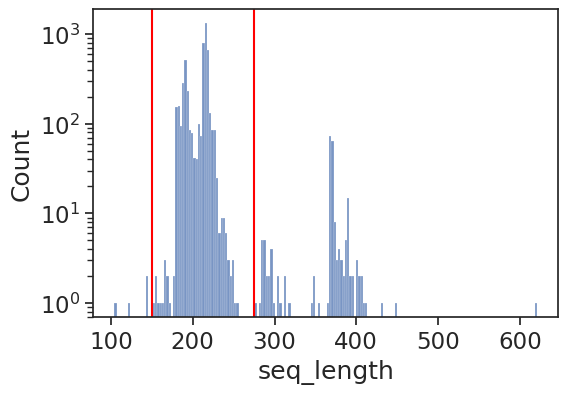

In [382]:
fig, ax = plt.subplots(figsize=(6,4))
sns.histplot(metrics_df['seq_length'])
ax.axvline(275, color='red')
ax.axvline(150, color='red')
ax.set_yscale('log')

In [383]:
print(metrics_df.query('seq_length <= 300 & seq_length >= 175').shape)

print(metrics_df.shape)

print(metrics_df.query('seq_length <= 300 & seq_length >= 175')['seq_length'].max())

(5009, 44)
(5229, 44)
300


In [384]:
filters += ['seq_length <= 300', 'seq_length >= 175']
filter_data = lambda df, f: df.query(' & '.join(list(set(f))))
filter_data(metrics_df, filters).head()

,Position,Contacts at 4.5 Å,SASA,genome,temp,total_score,avg_deg_4_5,avg_deg_8,avg_sc_nbrs_res_summary,bb_internal_hbonds,...,sasa,sc_internal_hbonds,total_cc_contacts,yhh_planarity,%S,%L,%H,length,avg_cc_contacts_per_res,seq_length
0,108.0,11.125581,49.464040,GB_GCA_000016765.1,30.0,-450.126,1.316,10.730,2.697,132.0,...,10462.361,34.0,599.0,0.034,0.167442,0.348837,0.483721,215.0,2.786047,215
1,119.5,11.289720,49.538232,GB_GCA_000242235.1,37.0,-328.360,1.310,10.708,2.712,130.0,...,12127.776,30.0,665.0,0.146,0.154867,0.358407,0.486726,226.0,2.942478,226
2,105.5,11.276190,50.018080,GB_GCA_000283575.1,30.0,-452.738,1.390,10.905,2.771,129.0,...,10333.413,23.0,589.0,0.012,0.171429,0.328571,0.500000,210.0,2.804762,210
3,94.0,11.358289,52.616491,GB_GCA_000376885.1,37.0,-454.076,1.278,10.765,2.648,124.0,...,9627.839,21.0,576.0,0.040,0.122995,0.267380,0.609626,187.0,3.080214,187
4,105.5,11.391753,51.807945,GB_GCA_000411155.1,37.0,-425.205,1.335,10.773,2.665,128.0,...,10604.045,28.0,640.0,0.140,0.123153,0.300493,0.576355,203.0,3.152709,203


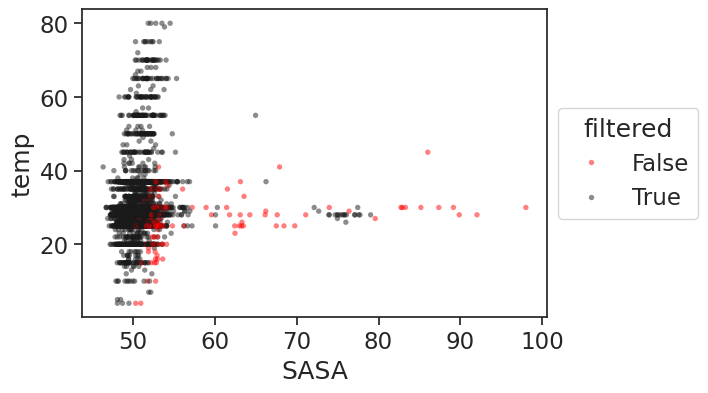

In [385]:
fig, ax = plt.subplots(figsize=(6,4))
sns.scatterplot(data=metrics_df, x='SASA', y='temp', edgecolor=None, color='black', s=15,
                linewidth=0, alpha=0.5, hue=metrics_df.genome.isin(filter_data(metrics_df, filters).genome), palette=['red', 'k']
               )
lgd = ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), title='filtered')

### Loop length

In [386]:
%%time
# Removing structures with long loops

max_loop_lengths = pd.Series(dtype='float')

for g in metrics_df['genome']:
    # print(g)
    s2r, sa = ss_to_domains(secondary_structure.loc[g])
    loop_lengths = [len(range(int(k.split('-')[0]), int(k.split('-')[1]))) for k, i in s2r.items()]
    max_loop_lengths.loc[g] = np.max(loop_lengths)

CPU times: user 5.46 s, sys: 93.2 ms, total: 5.55 s
Wall time: 5.41 s


In [387]:
metrics_df['max_structure_length'] = metrics_df['genome'].apply(lambda x: max_loop_lengths.loc[x])

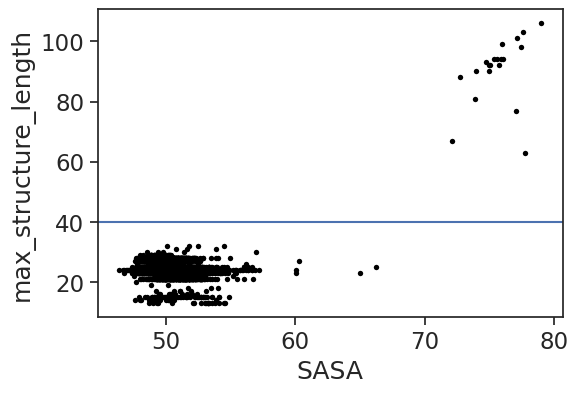

In [388]:
fig, ax = plt.subplots(figsize=(6,4))
sns.scatterplot(data=filter_data(metrics_df, filters).set_index('genome'), x='SASA', y='max_structure_length', edgecolor=None, color='black', s=15,
                linewidth=0, alpha=1
               )
ax.axhline(40)
# lgd = ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), title='filtered')

In [391]:
filters += ['max_structure_length <= 40']

In [389]:
filter_data(metrics_df, filters).query('max_structure_length >= 40').sort_values('SASA', ascending=False).head()

,Position,Contacts at 4.5 Å,SASA,genome,temp,total_score,avg_deg_4_5,avg_deg_8,avg_sc_nbrs_res_summary,bb_internal_hbonds,...,sc_internal_hbonds,total_cc_contacts,yhh_planarity,%S,%L,%H,length,avg_cc_contacts_per_res,seq_length,max_structure_length
3224,136.0,9.129151,79.021612,RS_GCF_002266435.2,28.0,1326.398,1.413,8.707,1.797,139.0,...,24.0,683.0,0.052,0.080000,0.530000,0.390000,300.0,2.276667,300,106
2133,133.5,9.458647,77.720971,RS_GCF_001189235.2,28.0,770.515,1.359,9.271,1.924,169.0,...,33.0,636.0,0.207,0.081356,0.393220,0.525424,295.0,2.155932,295,63
4793,134.5,9.156716,77.575472,RS_GCF_004114915.1,28.0,1257.160,1.458,8.751,1.835,139.0,...,25.0,678.0,0.080,0.080808,0.528620,0.390572,297.0,2.282828,297,103
3359,132.0,9.361217,77.452007,RS_GCF_002776695.1,30.0,1136.927,1.390,8.788,1.850,141.0,...,25.0,658.0,0.076,0.082192,0.520548,0.397260,292.0,2.253425,292,98
2347,133.5,9.165414,77.105682,RS_GCF_001440395.1,28.0,1155.111,1.441,8.797,1.815,135.0,...,28.0,653.0,0.119,0.081356,0.518644,0.400000,295.0,2.213559,295,101


In [390]:

genome = 'RS_GCF_002266435.2'
file = f'{genome}_closed.pdb'
struct_path = '/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/test_structures/'

draw_adk(f'{struct_path}{file}', color_domains=domain_cmap, ss=secondary_structure.loc[genome])

NGLWidget()

### Final: unexpected number of helices, sheets, or loops

In [412]:
structure_counts = pd.DataFrame(index=metrics_df['genome'], columns=['E', 'L', 'H'])
count = 0
for g in metrics_df['genome']:
    if count % 100 == 0:
        display(count)
        clear_output(wait=True)
    s2r, sa = ss_to_domains(secondary_structure.loc[g])
    c = Counter()
    for k, i in s2r.items():
        if len(range(int(k.split('-')[0]), int(k.split('-')[1]))) >= 5:
            c[i[0]] += 1
    structure_counts.loc[g, :] = pd.Series(c)
    count += 1

5200

In [ ]:
metrics_df.drop(['E', 'L', 'H'], axis=1, inplace=True)

metrics_df = pd.merge(metrics_df, structure_counts, left_on='genome', right_index=True)

metrics_df.head(2)

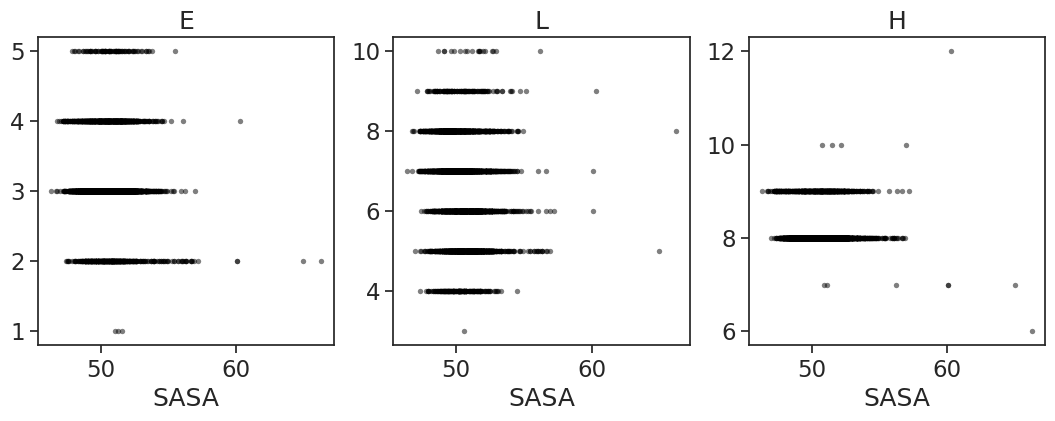

In [423]:
fig = plt.figure(figsize=(13,4))
for i, metric  in enumerate(['E', 'L', 'H']):
    ax = fig.add_subplot(1,3,i+1)
    sns.scatterplot(data=filter_data(metrics_df, filters), x='SASA', y=metric, edgecolor=None, color='black', s=15,
                    linewidth=0, alpha=0.5, hue=metrics_df.genome.isin(filter_data(metrics_df, filters).genome), palette=['red', 'k']
                   )
    ax.set_title(metric)
    ax.set_ylabel('')
# lgd = ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), title='filtered')

In [389]:
filter_data(metrics_df, filters).query('max_structure_length >= 40').sort_values('SASA', ascending=False).head()

,Position,Contacts at 4.5 Å,SASA,genome,temp,total_score,avg_deg_4_5,avg_deg_8,avg_sc_nbrs_res_summary,bb_internal_hbonds,...,sc_internal_hbonds,total_cc_contacts,yhh_planarity,%S,%L,%H,length,avg_cc_contacts_per_res,seq_length,max_structure_length
3224,136.0,9.129151,79.021612,RS_GCF_002266435.2,28.0,1326.398,1.413,8.707,1.797,139.0,...,24.0,683.0,0.052,0.080000,0.530000,0.390000,300.0,2.276667,300,106
2133,133.5,9.458647,77.720971,RS_GCF_001189235.2,28.0,770.515,1.359,9.271,1.924,169.0,...,33.0,636.0,0.207,0.081356,0.393220,0.525424,295.0,2.155932,295,63
4793,134.5,9.156716,77.575472,RS_GCF_004114915.1,28.0,1257.160,1.458,8.751,1.835,139.0,...,25.0,678.0,0.080,0.080808,0.528620,0.390572,297.0,2.282828,297,103
3359,132.0,9.361217,77.452007,RS_GCF_002776695.1,30.0,1136.927,1.390,8.788,1.850,141.0,...,25.0,658.0,0.076,0.082192,0.520548,0.397260,292.0,2.253425,292,98
2347,133.5,9.165414,77.105682,RS_GCF_001440395.1,28.0,1155.111,1.441,8.797,1.815,135.0,...,28.0,653.0,0.119,0.081356,0.518644,0.400000,295.0,2.213559,295,101


In [424]:
# add a filter on the number of helices
filters += ['H >= 8']

In [405]:

genome = 'RS_GCF_000946815.1'
file = f'{genome}_closed.pdb'
struct_path = '/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/test_structures/'

draw_adk(f'{struct_path}{file}', color_domains=domain_cmap, ss=secondary_structure.loc[genome])

NGLWidget()

### Exploring binary sasa / %H

<Axes: xlabel='%H', ylabel='temp'>

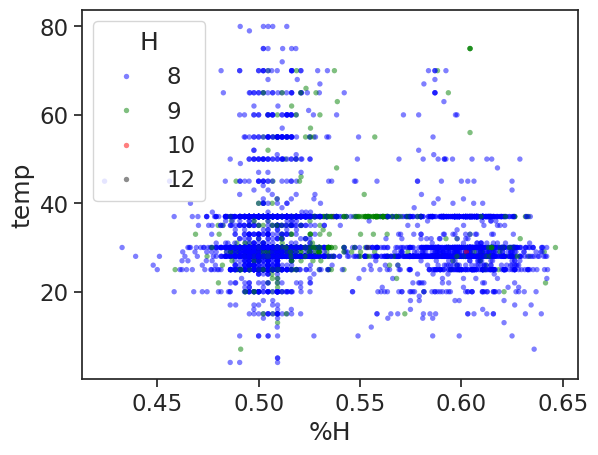

In [456]:
fig, ax = plt.subplots()
sns.scatterplot(data=filter_data(metrics_df, filters), x='%H', y='temp', edgecolor=None, color='black', s=15,
                linewidth=0, alpha=0.5, hue=filter_data(metrics_df, filters)['H'], palette=['blue', 'green', 'red', 'k']
               )
# ax.get_legend().remove()

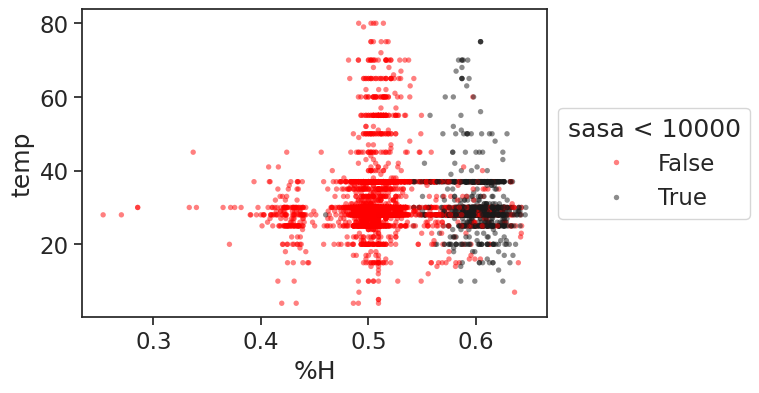

In [445]:
fig, ax = plt.subplots(figsize=(6,4))
sns.scatterplot(data=metrics_df, x='%H', y='temp', edgecolor=None, color='black', s=15,
                linewidth=0, alpha=0.5, hue=metrics_df['sasa'] < 10000, palette=['red', 'k']
               )
lgd = ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), title='sasa < 10000')

In [457]:
filter_data(metrics_df, filters).sort_values('%H')

,Position,Contacts at 4.5 Å,SASA,genome,temp,total_score,avg_deg_4_5,avg_deg_8,avg_sc_nbrs_res_summary,bb_internal_hbonds,...,%S,%L,%H,length,avg_cc_contacts_per_res,seq_length,max_structure_length,E,L,H
1302,137.5,11.220183,51.659413,RS_GCF_000442315.1,45.0,162.551,1.360,10.088,2.388,140.0,...,0.132000,0.444000,0.424000,250.0,2.612000,250,31,2,10,8
2948,136.5,11.175926,49.423586,RS_GCF_001982615.1,30.0,-74.324,1.376,10.029,2.425,133.0,...,0.155102,0.412245,0.432653,245.0,2.518367,245,30,4,8,8
4230,129.0,11.124424,49.430109,RS_GCF_003550065.1,28.0,-279.589,1.326,10.347,2.553,137.0,...,0.146444,0.414226,0.439331,239.0,2.493724,239,24,2,9,8
627,130.5,11.245763,52.970800,RS_GCF_000265425.1,26.0,-492.614,1.328,10.704,2.547,143.0,...,0.144000,0.408000,0.448000,250.0,3.080000,250,24,3,10,8
538,132.5,11.324074,53.064408,RS_GCF_000237205.1,25.0,-342.488,1.308,10.125,2.392,135.0,...,0.170833,0.379167,0.450000,240.0,2.812500,240,25,4,8,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4915,95.0,11.502646,51.763336,RS_GCF_004331345.1,28.0,-440.329,1.295,10.937,2.711,125.0,...,0.121053,0.236842,0.642105,190.0,2.852632,190,24,3,4,8
363,95.0,11.502646,47.777125,RS_GCF_000175215.2,30.0,-445.457,1.305,10.947,2.720,123.0,...,0.126316,0.231579,0.642105,190.0,3.110526,190,24,3,4,8
4835,96.5,11.197917,51.512473,RS_GCF_004137085.1,23.0,-415.890,1.294,10.735,2.607,136.0,...,0.112745,0.245098,0.642157,204.0,2.553922,204,24,3,5,8
988,97.0,11.388601,50.743189,RS_GCF_000382225.1,25.0,-453.323,1.251,10.826,2.671,141.0,...,0.125604,0.231884,0.642512,207.0,2.797101,207,31,4,4,8


In [460]:

genome = 'RS_GCF_002811925.1'
file = f'{genome}_closed.pdb'
struct_path = '/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/test_structures/'

draw_adk(f'{struct_path}{file}', color_domains=domain_cmap, ss=secondary_structure.loc[genome])
# draw_adk(f'{struct_path}{file}', color_ss=ss_cmap, ss=secondary_structure.loc[genome])

NGLWidget()

In [404]:
filter_data(metrics_df, filters).query('SASA >= 60').sort_values('SASA', ascending=False).head()

,Position,Contacts at 4.5 Å,SASA,genome,temp,total_score,avg_deg_4_5,avg_deg_8,avg_sc_nbrs_res_summary,bb_internal_hbonds,...,%S,%L,%H,length,avg_cc_contacts_per_res,seq_length,max_structure_length,E,L,H
1944,93.0,10.400000,66.250807,RS_GCF_000946815.1,37.0,-338.250,1.290,9.871,2.086,106.0,...,0.145161,0.381720,0.473118,186.0,2.790323,186,25,10,18,7
4829,91.5,10.318681,64.976022,RS_GCF_004135675.1,55.0,-331.272,1.186,9.721,2.073,106.0,...,0.114754,0.366120,0.519126,183.0,2.748634,183,23,9,19,9
4566,146.0,10.724528,60.303077,RS_GCF_003935895.2,30.0,-458.064,1.237,10.273,2.403,172.0,...,0.129496,0.316547,0.553957,278.0,2.956835,278,27,11,24,13
4745,95.5,10.347368,60.088907,RS_GCF_004005865.1,25.0,-371.914,1.251,9.932,2.169,113.0,...,0.157068,0.356021,0.486911,191.0,2.335079,191,23,10,17,7
5196,96.5,10.322917,60.076621,RS_GCF_004792685.1,28.0,-369.684,1.281,10.062,2.169,114.0,...,0.156250,0.348958,0.494792,192.0,2.354167,192,24,10,18,8


## Plotting correlations with OGT

In [425]:
plot_filenames = {col_name: col_name.replace(' ','_').strip('Å²()_').replace('Δ','d').replace('%','percent_') for col_name in metrics_df.columns}
metrics_to_plot = [metric for metric in metrics_df.columns if 'Å' in metric or 'SASA' in metric]
metrics_to_plot = metrics_to_plot + [metric for metric in metrics_df.columns if '%' in metric or 'internal_hbonds' in metric or 'sasa' in metric]
metrics_to_plot = metrics_to_plot + ['cav_vol', 'packstat',  'avg_deg_4_5', 'avg_deg_8', 'avg_sc_nbrs_res_summary', 'avg_cc_contacts_per_res']
print(metrics_to_plot)
include_legend = False

['Contacts at 4.5 Å', 'SASA', 'bb_internal_hbonds', 'bbsc_internal_hbonds', 'internal_hbonds', 'nonpolar_sasa', 'polar_sasa', 'sasa', 'sc_internal_hbonds', '%S', '%L', '%H', 'cav_vol', 'packstat', 'avg_deg_4_5', 'avg_deg_8', 'avg_sc_nbrs_res_summary', 'avg_cc_contacts_per_res']


In [429]:
len(metrics_to_plot)

18

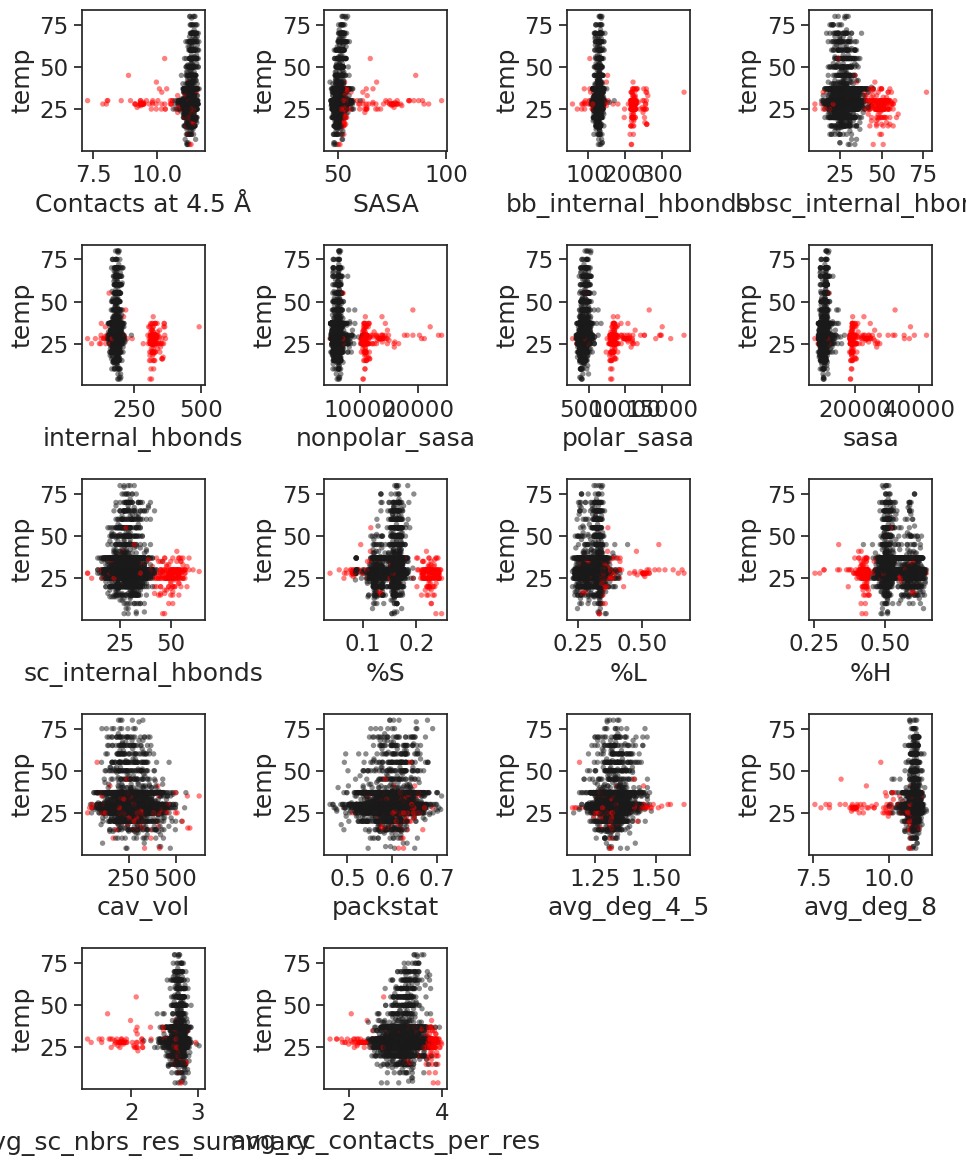

In [433]:
# first, plotting after filtering
fig = plt.figure(figsize=(10, 12))
for i, metric in enumerate(metrics_to_plot):
    ax = fig.add_subplot(5,4,i+1)
    sns.scatterplot(data=metrics_df, x=metric, y='temp', edgecolor=None, color='black', s=15,
                    linewidth=0, alpha=0.5, hue=metrics_df.genome.isin(filter_data(metrics_df, filters).genome), palette=['red', 'k']
                   )
    ax.get_legend().remove()
    # lgd = ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), title='filtered')

    sns.despine(f)
    plt.tight_layout()

    # fileout = plot_filenames[metric] + '.svg'
    # plt.savefig(os.path.join(output_dir, figure_dir, fileout))

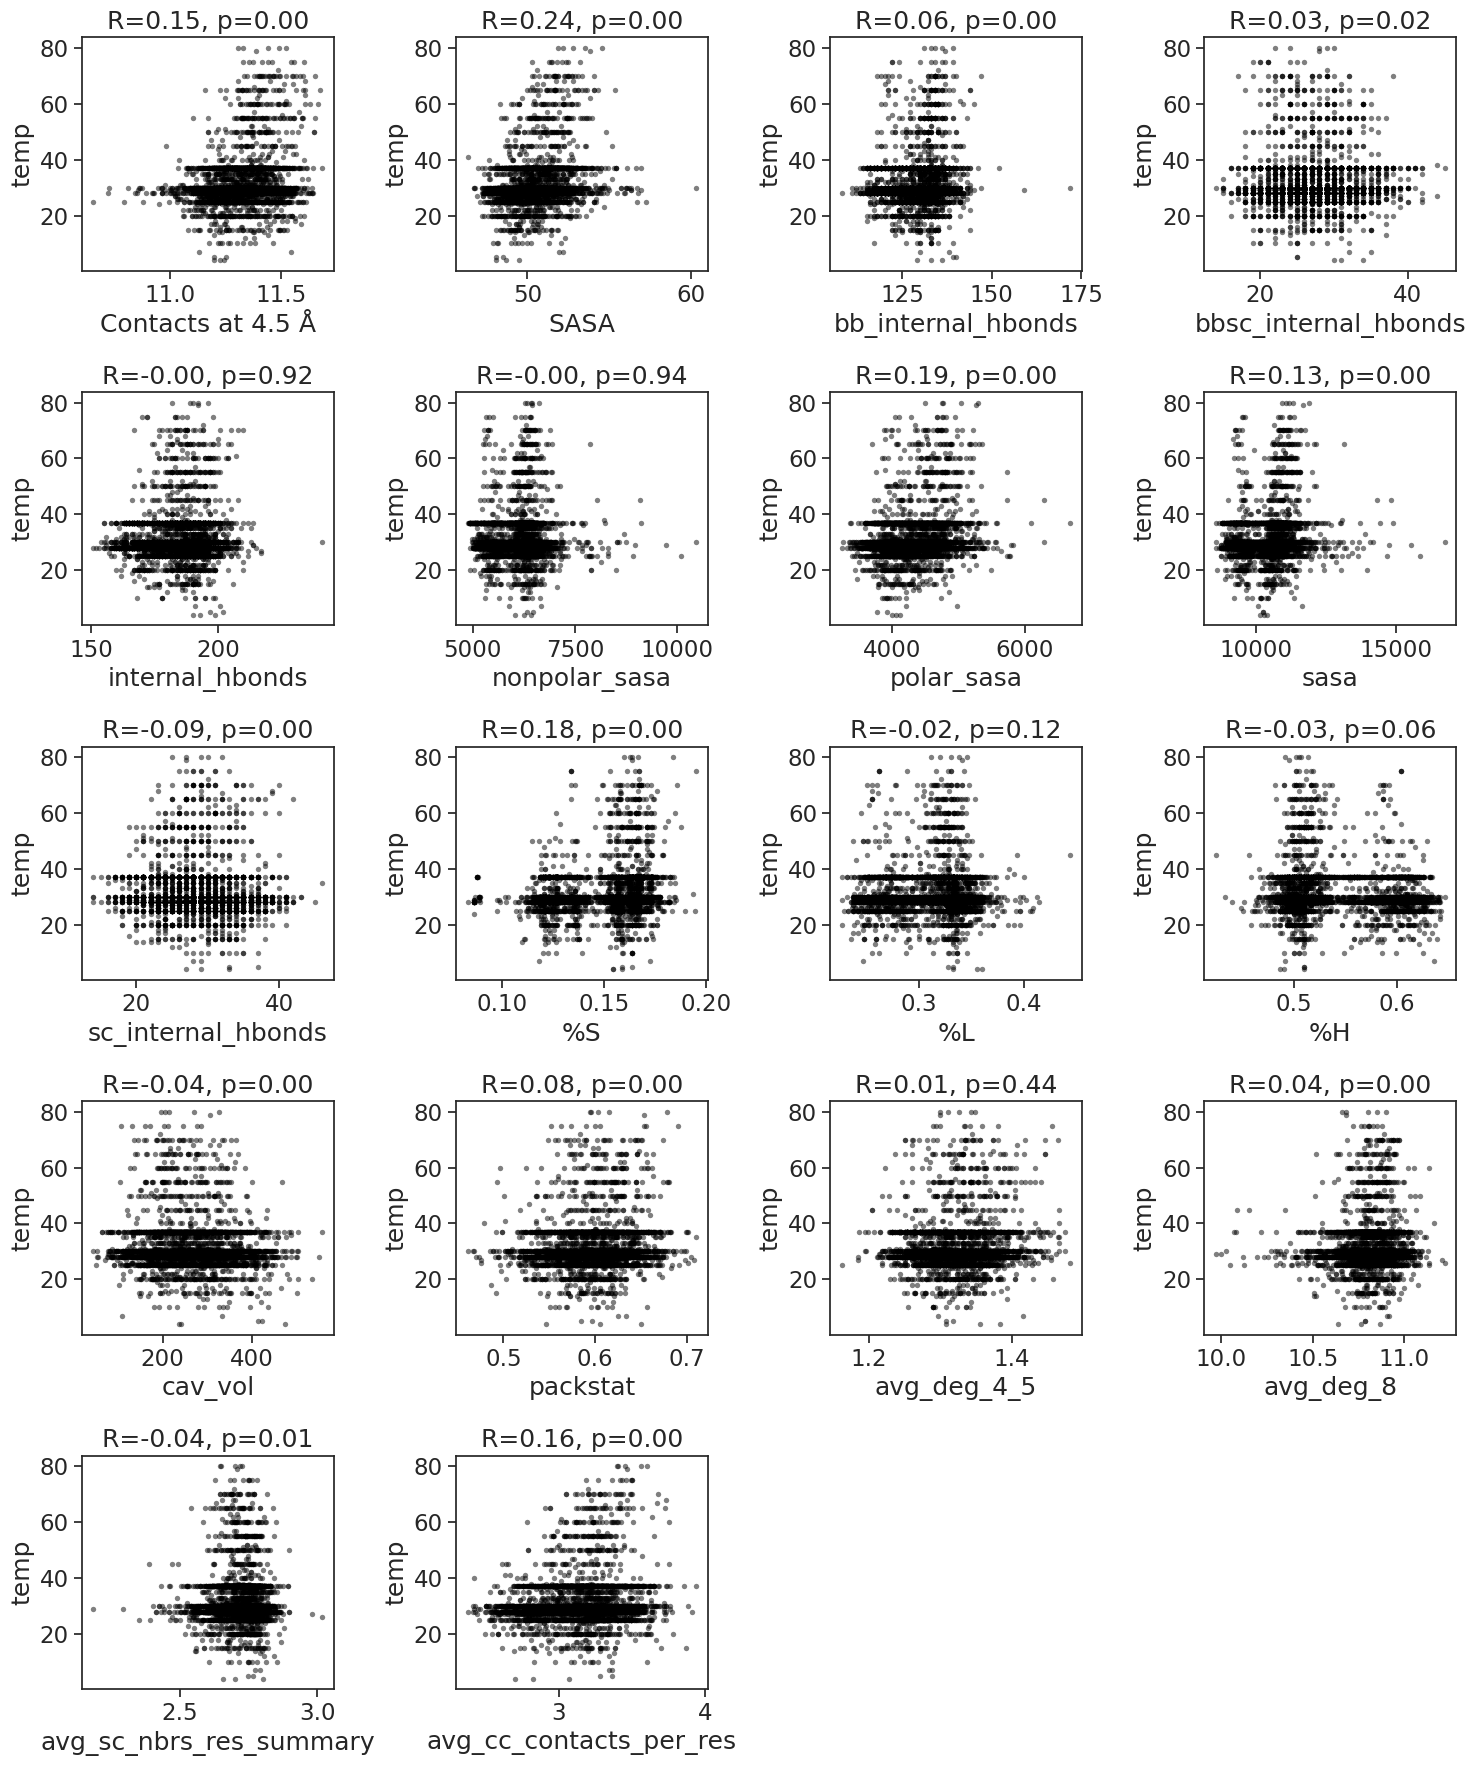

In [436]:
# first, plotting after filtering
fig = plt.figure(figsize=(15, 18))
filtered = filter_data(metrics_df, filters)
for i, metric in enumerate(metrics_to_plot):
    ax = fig.add_subplot(5,4,i+1)
    sns.scatterplot(data=filtered, x=metric, y='temp', edgecolor=None, color='black', s=15,
                    linewidth=0, alpha=0.5
                   )
    spR_result = spearmanr(filtered[metric], filtered['temp'])
    ax.set_title(f'R={spR_result[0]:.02f}, p={spR_result[1]:.02f}')
    # ax.get_legend().remove()
    # lgd = ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), title='filtered')

    sns.despine(f)
    plt.tight_layout()

    # fileout = plot_filenames[metric] + '.svg'
    # plt.savefig(os.path.join(output_dir, figure_dir, fileout))

(150.0, 250.0)

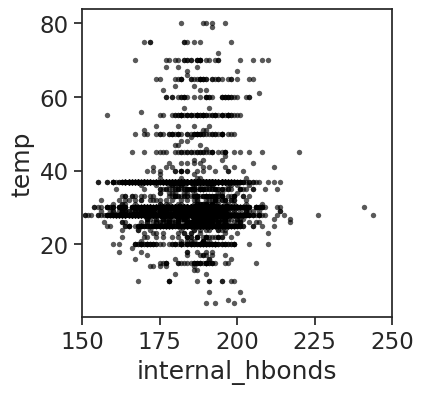

In [147]:
fig, ax = plt.subplots(figsize=(4,4))
sns.scatterplot(data=metrics_df, x='internal_hbonds', y='temp', edgecolor=None, color='black', s=15,
                linewidth=0, alpha=0.65
               )
ax.set_xlim(150, 250)

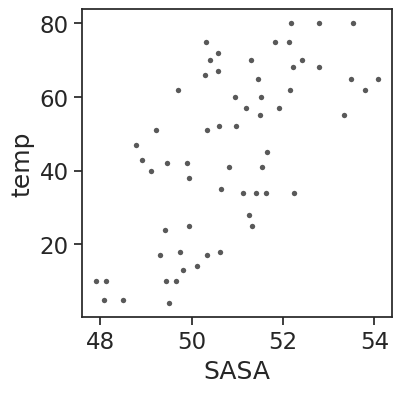

In [135]:
fig, ax = plt.subplots(figsize=(4,4))
subset = metrics_df.set_index('genome').loc[original_df['genome'], :]
sns.scatterplot(data=subset, x='SASA', y='temp', edgecolor=None, color='black', s=15,
                linewidth=0, alpha=0.65)
plt.show()

In [116]:
# subset = metrics_df[metrics_df['SASA'] < 55]
spearmanr(subset['SASA'], subset['temp'])

SignificanceResult(statistic=0.6269250570653655, pvalue=6.462382342386609e-08)

In [735]:
filtered['group'].value_counts()

group
(25.0, 30.0]     2877
(35.0, 40.0]      957
(20.0, 25.0]      429
(30.0, 35.0]      232
(15.0, 20.0]      131
(50.0, 55.0]       61
(45.0, 50.0]       54
(40.0, 45.0]       53
(10.0, 15.0]       45
(55.0, 60.0]       38
(60.0, 65.0]       38
(65.0, 70.0]       33
(5.0, 10.0]        13
(70.0, 75.0]       10
(75.0, 80.0]        6
(0.0, 5.0]          5
(80.0, 85.0]        0
(85.0, 90.0]        0
(90.0, 95.0]        0
(95.0, 100.0]       0
Name: count, dtype: int64

In [462]:
from scipy.stats import linregress


In [693]:
Rs = pd.Series()

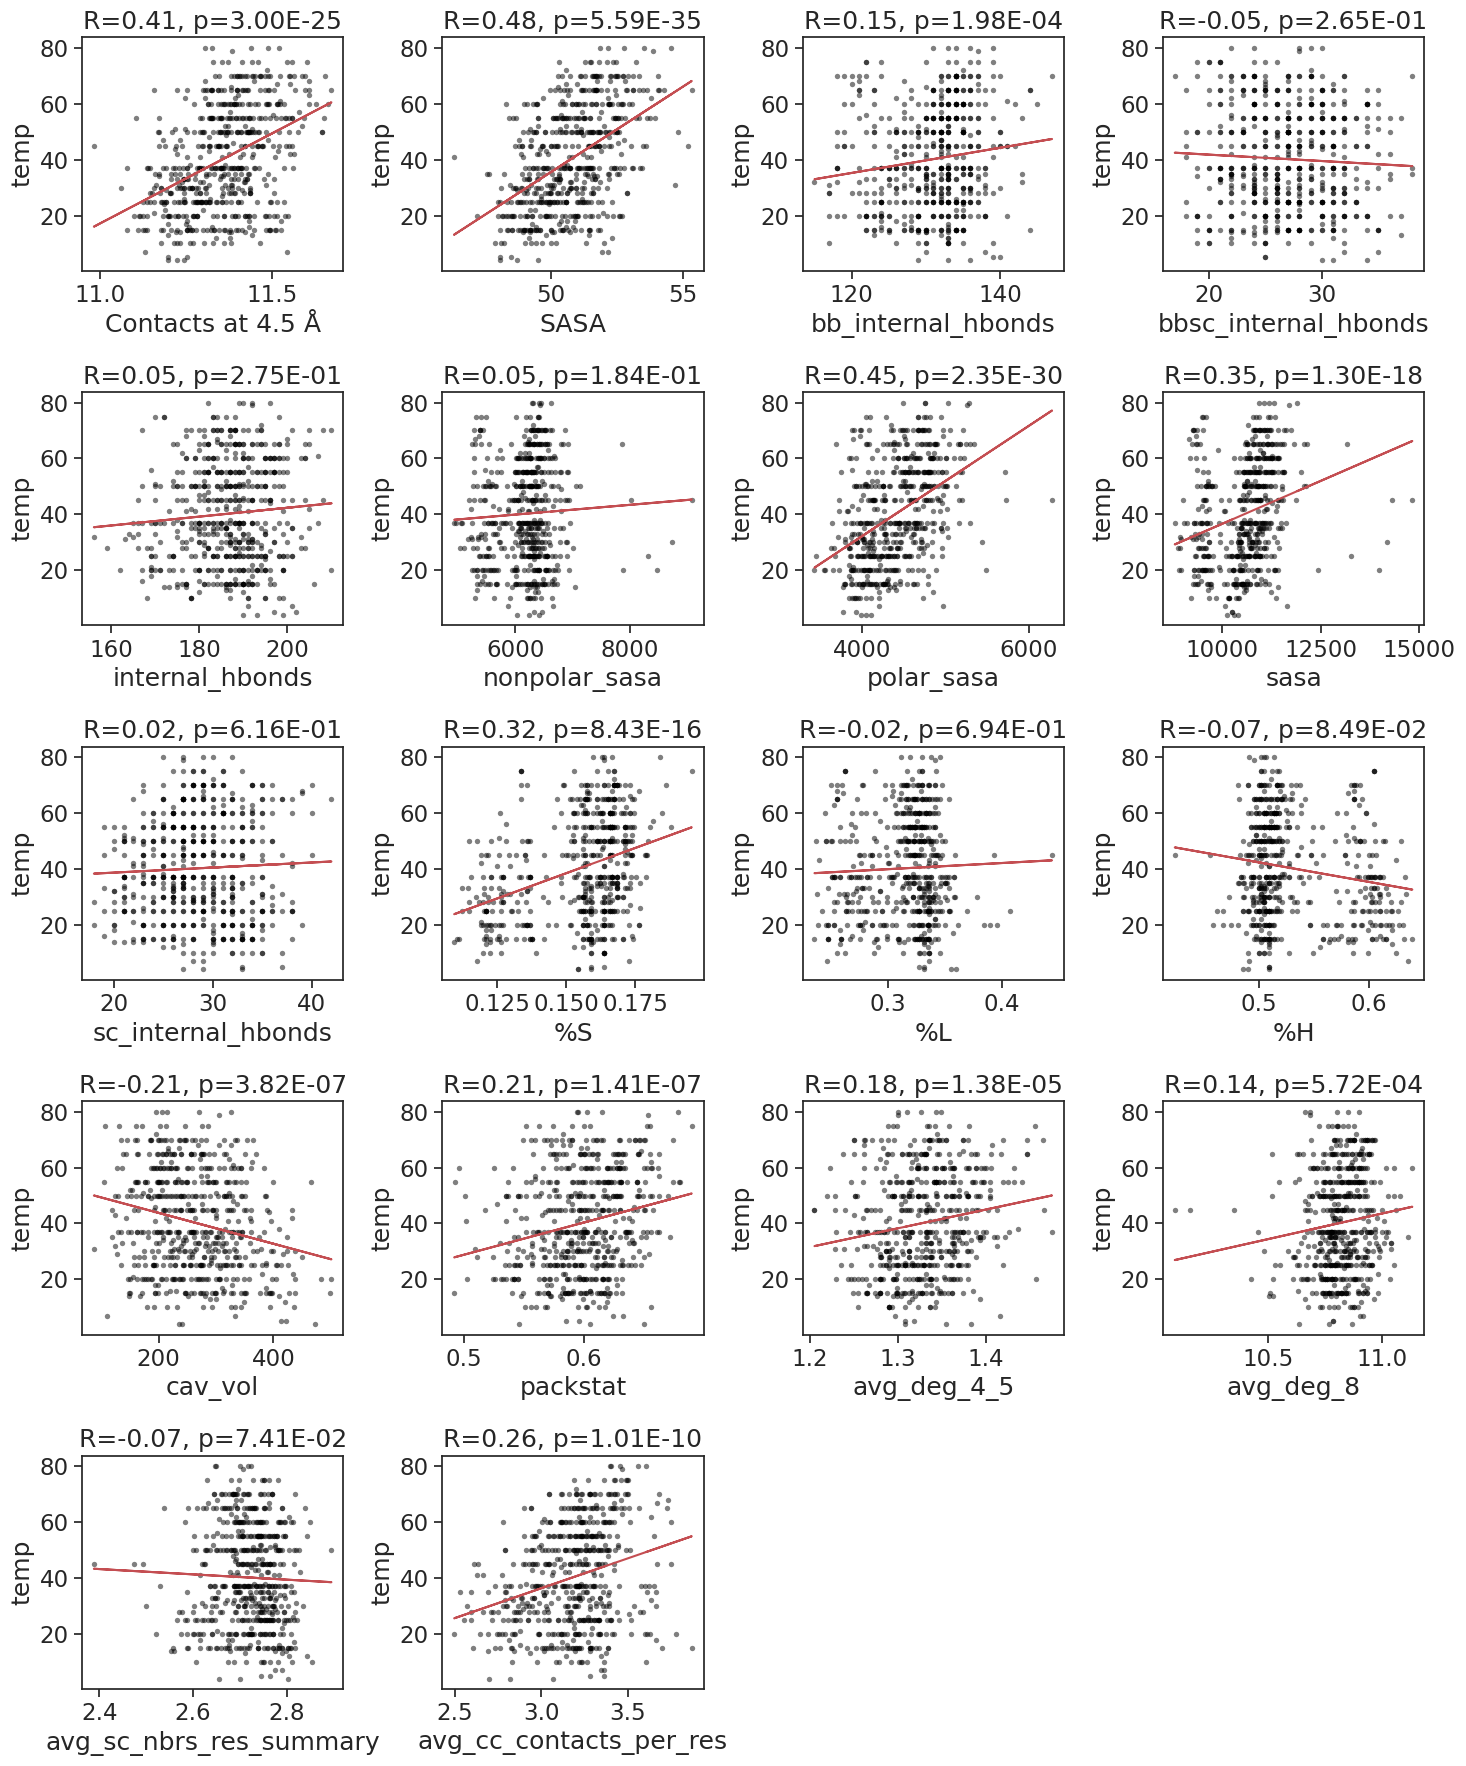

In [694]:
# first, plotting after filtering
fig = plt.figure(figsize=(15, 18))
filtered = filter_data(metrics_df, filters).copy(deep=True)
filtered['group'] = pd.cut(metrics_df['temp'], np.linspace(0, 100, 21))
resampled = filtered.groupby('group', observed=True).apply(lambda x: x.sample(np.min([50, len(x)]), replace=False))
for i, metric in enumerate(metrics_to_plot):
    ax = fig.add_subplot(5,4,i+1)
    sns.scatterplot(data=resampled, x=metric, y='temp', edgecolor=None, color='black', s=15,
                    linewidth=0, alpha=0.5
                   )
    reg = linregress(y=resampled['temp'], x=resampled[metric])
    plt.plot(resampled[metric], reg.intercept + reg.slope * resampled[metric], 'r', label='fitted line')
    spR_result = spearmanr(resampled[metric], resampled['temp'])
    ax.set_title(f'R={spR_result[0]:.02f}, p={spR_result[1]:.02E}')
    Rs.loc[metric] = spR_result[0]
    # ax.get_legend().remove()
    # lgd = ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), title='filtered')

    sns.despine(f)
    plt.tight_layout()

In [695]:
additional_metrics =  ['dslf_fa13',
 'fa_atr',
 'fa_dun',
 'fa_elec',
 'fa_intra_rep',
 'fa_intra_sol_xover4',
 'fa_rep',
 'fa_sol',
 'hbond_bb_sc',
 'hbond_lr_bb',
 'hbond_sc',
 'hbond_sr_bb',
 'lk_ball_wtd',
 'omega',
 'p_aa_pp',
 'pro_close',
 'rama_prepro',
 'ref',
 'total_cc_contacts',
 'yhh_planarity',]

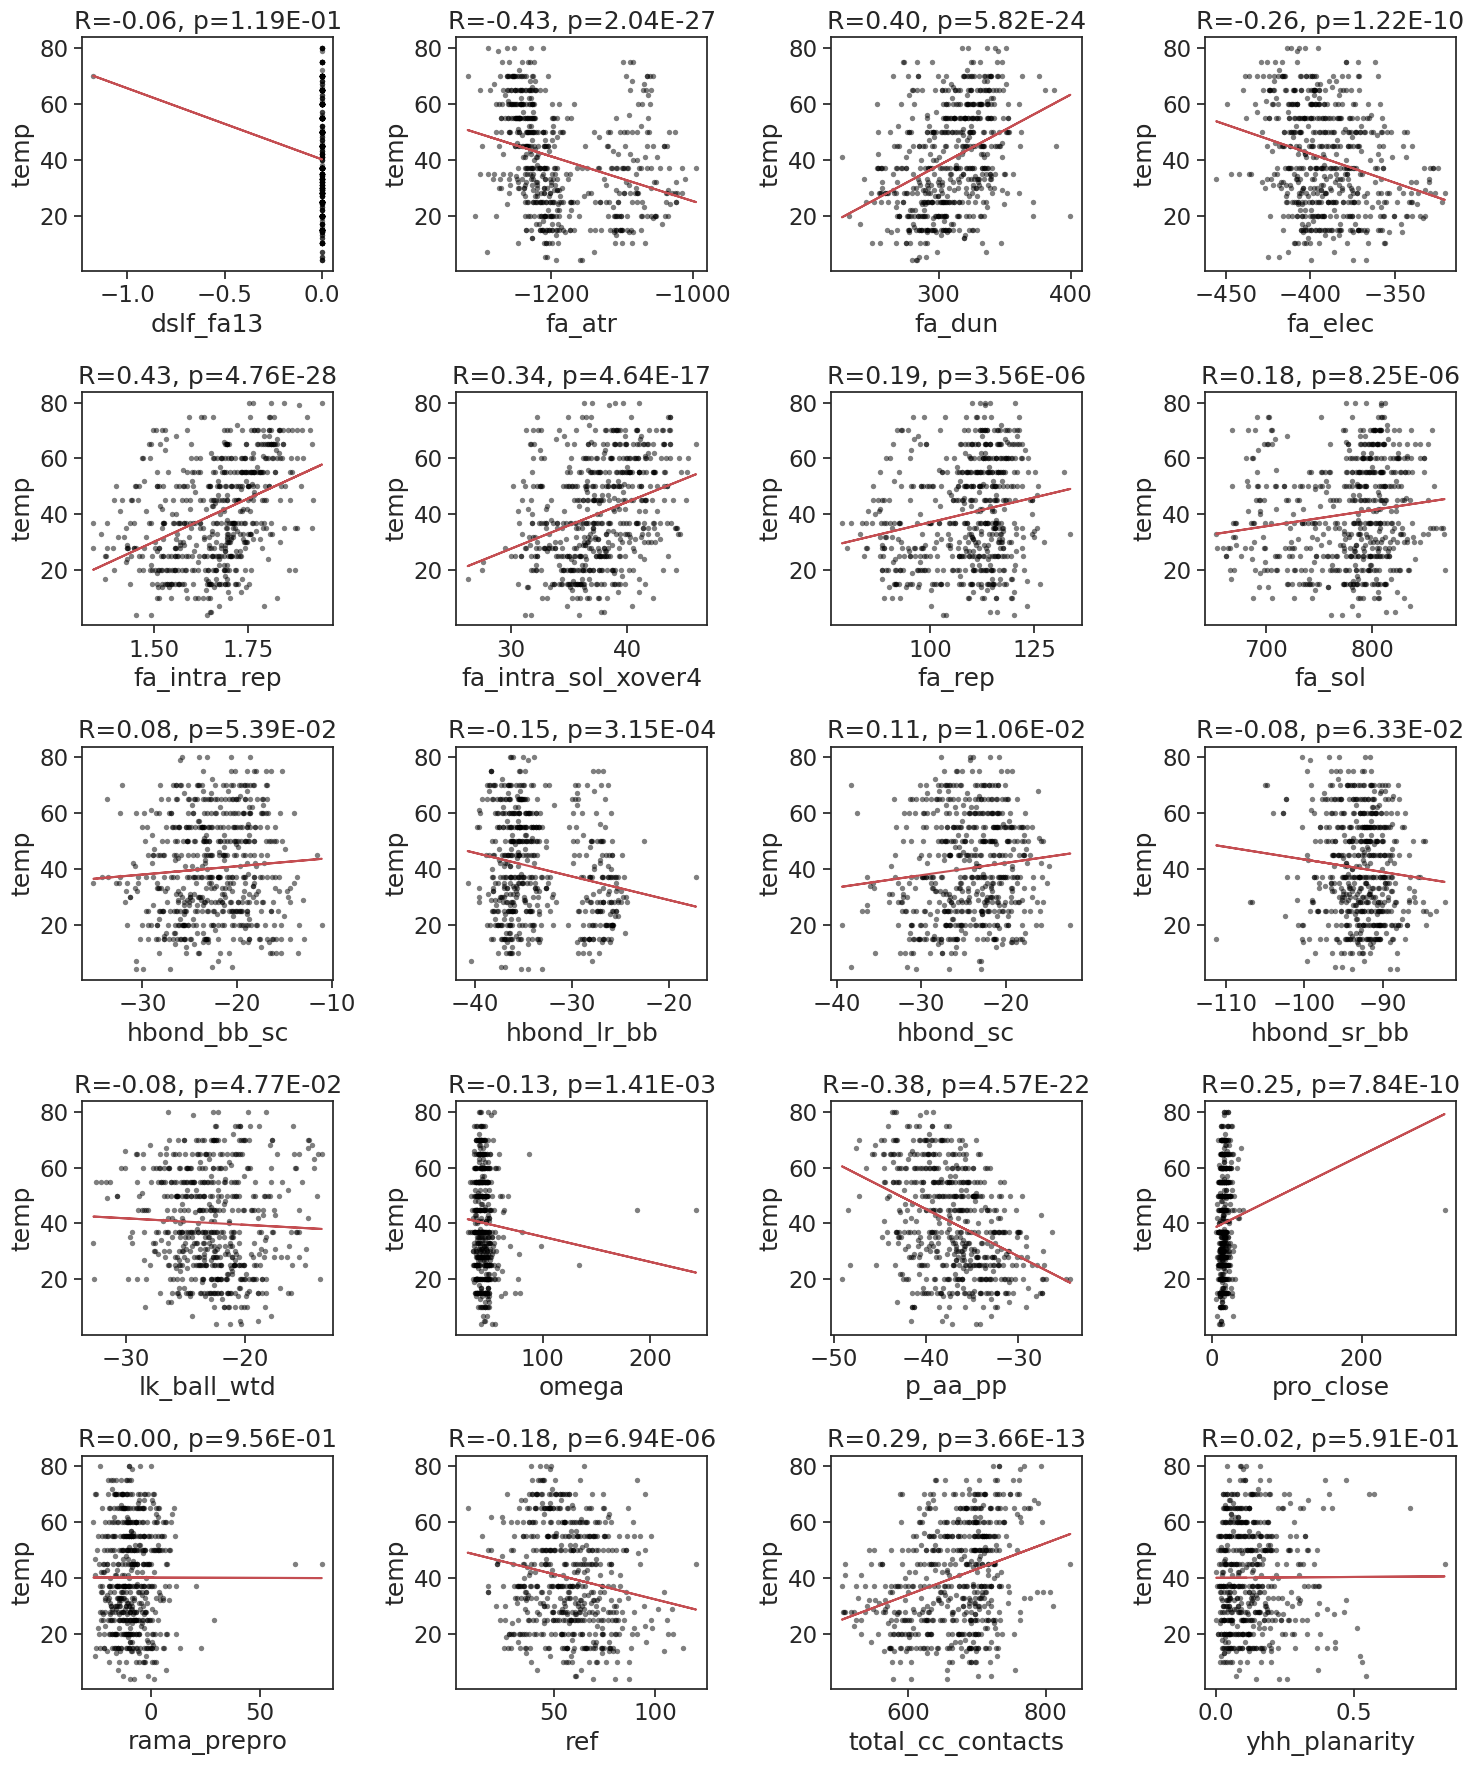

In [697]:
# first, plotting after filtering
fig = plt.figure(figsize=(15, 18))
filtered = filter_data(metrics_df, filters).copy(deep=True)
filtered['group'] = pd.cut(metrics_df['temp'], np.linspace(0, 100, 21))
resampled = filtered.groupby('group', observed=True).apply(lambda x: x.sample(np.min([50, len(x)]), replace=False))
for i, metric in enumerate(additional_metrics):
    ax = fig.add_subplot(5,4,i+1)
    sns.scatterplot(data=resampled, x=metric, y='temp', edgecolor=None, color='black', s=15,
                    linewidth=0, alpha=0.5
                   )
    reg = linregress(y=resampled['temp'], x=resampled[metric])
    plt.plot(resampled[metric], reg.intercept + reg.slope * resampled[metric], 'r', label='fitted line')
    spR_result = spearmanr(resampled[metric], resampled['temp'])
    Rs.loc[metric] = spR_result[0]
    
    ax.set_title(f'R={spR_result[0]:.02f}, p={spR_result[1]:.02E}')
    
    # ax.get_legend().remove()
    # lgd = ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), title='filtered')

    sns.despine(f)
    plt.tight_layout()

## Machine learning component

In [485]:
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score

In [503]:
# Create linear regression object
regr = linear_model.LinearRegression()

# Train the model using the training sets
regr.fit(X=resampled['SASA'].values.reshape(-1, 1), y=resampled['temp'].values.reshape(-1, 1))

LinearRegression()

In [504]:
regr.predict(np.linspace(2.5, 4).reshape(-1, 1))

array([[-221.90378866],
       [-221.7377651 ],
       [-221.57174154],
       ...,
       [-214.10068126],
       [-213.9346577 ],
       [-213.76863414]])

(0.0, 30.0)

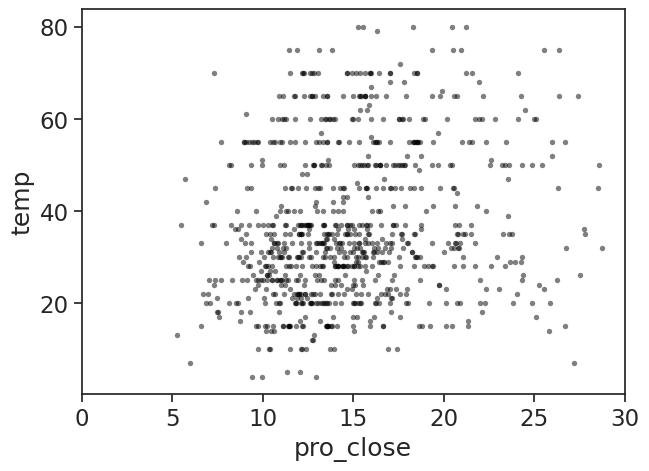

In [830]:
fig, ax = plt.subplots(figsize=(7,5))
sns.scatterplot(data=resampled, x='pro_close', y='temp', edgecolor=None, color='black', s=15,
                    linewidth=0, alpha=0.5
                   )
x = resampled['SASA']
# l = np.linspace(x.min(), x.max(), 100)
# plt.plot(l, regr.predict(l.reshape(-1, 1)), 'r', label='fitted line')
ax.set_xlim(0, 30)

In [625]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error, make_scorer, root_mean_squared_error
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
# from hyperopt.fmin import fmin

In [608]:
filtered = filter_data(metrics_df, filters)

### Simple model test

<Axes: ylabel='Count'>

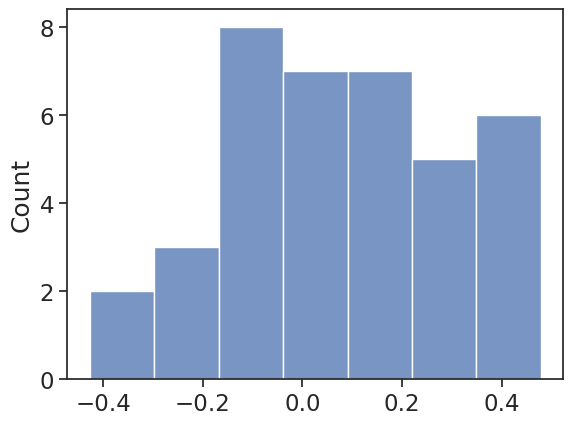

In [699]:
sns.histplot(Rs)

#### With subsampling

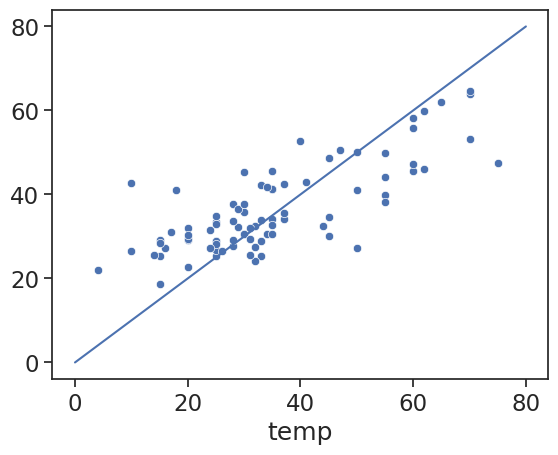

In [833]:
filtered['group'] = pd.cut(metrics_df['temp'], np.linspace(0, 100, 51))
resampled = filtered.groupby('group', observed=True).apply(lambda x: x.sample(np.min([50, len(x)]), replace=False)).reset_index(drop=True).set_index('genome')

X_train, X_test, y_train, y_test = train_test_split(resampled[metrics_to_plot + additional_metrics], resampled['temp'], test_size=0.1)

# computing the score on the test set
random_state = 5
model = RandomForestRegressor(random_state=random_state, n_estimators=1500,
                      max_depth=50, min_samples_leaf=1,
                      min_samples_split=2,
                      n_jobs=24)

# model = RandomForestRegressor(random_state=random_state, n_estimators=best['n_estimators'],
#                       max_depth=best['max_depth']+5, min_samples_leaf=best['min_samples_leaf']+1,
#                       min_samples_split=best['min_samples_split']+1,
#                       n_jobs=20)

model.fit(X_train, y_train)
sa_test_score=root_mean_squared_error(y_test, model.predict(X_test))


# choices = np.random.choice(list(range(len(filtered))), size=int(len(filtered) * 0.9), replace=False)
# model.fit(filtered.iloc[choices, :][metrics_to_plot + additional_metrics].values, filtered.iloc[choices, :]['temp'])
# not_choices = [i for i in list(range(len(filtered))) if not i in choices]
# sa_test_score=root_mean_squared_error(filtered.iloc[not_choices, :]['temp'], model.predict(filtered.iloc[not_choices, :][metrics_to_plot + additional_metrics].values))


sa_test_score

sns.scatterplot(x=y_test, y=model.predict(X_test))
plt.plot((0,80), (0, 80))

In [835]:
resampled
len(y_test)

86

In [831]:
y_test

group             
(30.0, 32.0]  4326    31.0
(26.0, 28.0]  1658    28.0
(48.0, 50.0]  1286    50.0
(28.0, 30.0]  4820    30.0
(6.0, 8.0]    296      7.0
                      ... 
(36.0, 38.0]  1974    37.0
(46.0, 48.0]  4069    48.0
(28.0, 30.0]  5156    30.0
              2817    29.0
(26.0, 28.0]  3374    28.0
Name: temp, Length: 86, dtype: float64

#### Without subsampling

6.367663553302814


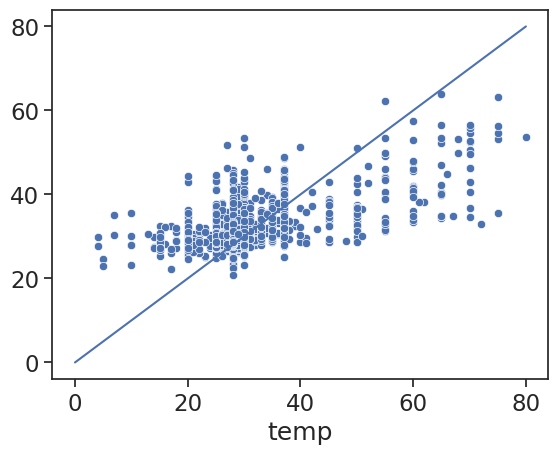

In [762]:

# resampled = filtered.groupby('group', observed=True).apply(lambda x: x.sample(np.min([50, len(x)]), replace=False))


# X_train, X_test, y_train, y_test = train_test_split(resampled[metrics_to_plot + additional_metrics], resampled['temp'], test_size=0.1)

# X_train, X_test, y_train, y_test = train_test_split(resampled[[index for index, R in Rs.items() if np.abs(R) >= 0.2]], resampled['temp'], test_size=0.1)

X_train, X_test, y_train, y_test = train_test_split(filtered[metrics_to_plot + additional_metrics], filtered['temp'], test_size=0.5)

# computing the score on the test set
random_state = 5
model = RandomForestRegressor(random_state=random_state, n_estimators=500,
                      n_jobs=24)

# model = RandomForestRegressor(random_state=random_state, n_estimators=best['n_estimators'],
#                       max_depth=best['max_depth']+5, min_samples_leaf=best['min_samples_leaf']+1,
#                       min_samples_split=best['min_samples_split']+1,
#                       n_jobs=20)

model.fit(X_train, y_train)
sa_test_score=root_mean_squared_error(y_test, model.predict(X_test))


# choices = np.random.choice(list(range(len(filtered))), size=int(len(filtered) * 0.9), replace=False)
# model.fit(filtered.iloc[choices, :][metrics_to_plot + additional_metrics].values, filtered.iloc[choices, :]['temp'])
# not_choices = [i for i in list(range(len(filtered))) if not i in choices]
# sa_test_score=root_mean_squared_error(filtered.iloc[not_choices, :]['temp'], model.predict(filtered.iloc[not_choices, :][metrics_to_plot + additional_metrics].values))


print(sa_test_score)

sns.scatterplot(x=y_test, y=model.predict(X_test))
plt.plot((0, 80), (0, 80))

In [731]:
pearsonr(y_test, model.predict(X_test))

PearsonRResult(statistic=0.6361016474807681, pvalue=6.083490195213503e-58)

In [730]:
from scipy.stats import pearsonr

In [709]:
len(resampled)

588

### GLMNet

In [750]:
from glmnet import ElasticNet

In [810]:
filtered['group'] = pd.cut(metrics_df['temp'], np.linspace(0, 100, 51))
resampled = filtered.groupby('group', observed=True).apply(lambda x: x.sample(np.min([50, len(x)]), replace=False))

X_train, X_test, y_train, y_test = train_test_split(resampled[metrics_to_plot + additional_metrics], resampled['temp'], test_size=0.1)

# X_train, X_test, y_train, y_test = train_test_split(resampled[[index for index, R in Rs.items() if np.abs(R) >= 0.2]], resampled['temp'], test_size=0.1)

In [811]:
len(X_train)

771

In [812]:
m = ElasticNet()
m = m.fit(X_train, y_train)

In [813]:
# p = m.predict(x)
sa_test_score=root_mean_squared_error(y_test, m.predict(X_test))
sa_test_score

10.553754578686238

Text(0, 0.5, 'Predicted OGT')

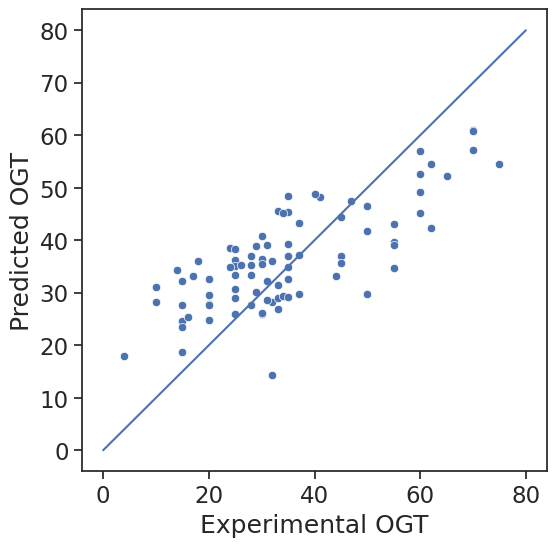

In [864]:
fig, ax = plt.subplots(figsize=(6,6))
sns.scatterplot(x=y_test, y=m.predict(X_test))
plt.plot((0, 80), (0, 80))
ax.set_xlabel('Experimental OGT')
ax.set_ylabel('Predicted OGT')

In [784]:
spearmanr(y_test, m.predict(X_test))

SignificanceResult(statistic=0.8141618146397839, pvalue=4.470239464476531e-15)

In [816]:
spearmanr(y_test, m.predict(X_test))

SignificanceResult(statistic=0.7332740615780302, pvalue=9.912087031854326e-16)

<Axes: xlabel='temp', ylabel='Count'>

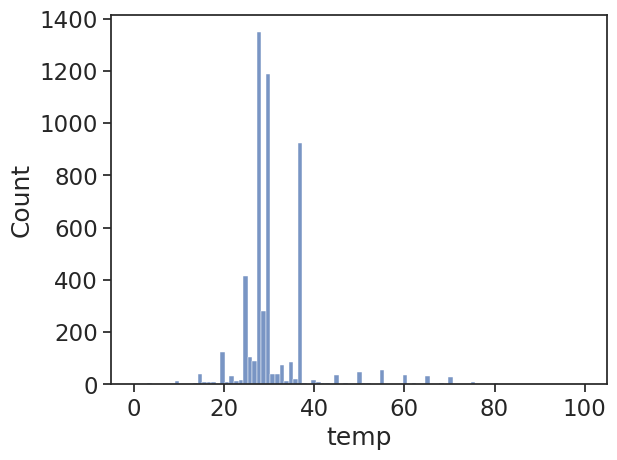

In [817]:
sns.histplot(metrics_df['temp'], bins=np.linspace(0, 100, 100))

In [788]:
metrics_df['temp'].value_counts()

temp
28.0    1348
30.0    1188
37.0     923
25.0     413
29.0     280
        ... 
66.0       1
72.0       1
61.0       1
56.0       1
44.0       1
Name: count, Length: 61, dtype: int64

In [820]:
metrics_df['temp'].eq(4).sum()

5

### Parameter optimization with hyperopt

In [652]:
seed=2
def objective(params):
    est=int(params['n_estimators'])
    md=int(params['max_depth'])
    msl=int(params['min_samples_leaf'])
    mss=int(params['min_samples_split'])
    model=RandomForestRegressor(n_estimators=est,
                                max_depth=md,
                                min_samples_leaf=msl,
                                min_samples_split=mss,
                                n_jobs=24)
    model.fit(X_train, y_train)
    # pred=model.predict(X_test)
    losses = cross_val_score(model, X_train, y_train, cv=5, scoring="neg_mean_squared_error", n_jobs=4)
    return {'status': STATUS_OK,
            'loss':np.mean(losses),
            'loss_variance': np.var(losses, ddof=1)}

def optimize(trial):
    params={'n_estimators':hp.choice('n_estimators',[100, 500, 3000]),
           'max_depth':hp.choice('max_depth',[1, 5, 10, 25]),
           'min_samples_leaf':hp.choice('min_samples_leaf',[1, 2, 5, 10]),
           'min_samples_split':hp.choice('min_samples_split',[2, 5, 10])}
    best=fmin(fn=objective, space=params, algo=tpe.suggest, trials=trial, max_evals=10, rstate=np.random.default_rng(seed))
    return best


In [653]:
trial = Trials()
best = optimize(trial)

100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [05:58<00:00, 35.87s/trial, best loss: -60.027558974275884]


In [654]:
trial.results

[{'status': 'ok',
  'loss': -59.98623361539347,
  'loss_variance': 29.001923234804764},
 {'status': 'ok',
  'loss': -38.723660936959504,
  'loss_variance': 5.9113694487135255},
 {'status': 'ok',
  'loss': -39.57728387038338,
  'loss_variance': 7.343209845766388},
 {'status': 'ok',
  'loss': -38.544351824309054,
  'loss_variance': 7.616264141380216},
 {'status': 'ok',
  'loss': -45.15542615943298,
  'loss_variance': 6.369651589056865},
 {'status': 'ok',
  'loss': -39.7771140505797,
  'loss_variance': 7.3131293914681486},
 {'status': 'ok',
  'loss': -40.10509696079102,
  'loss_variance': 7.118772450258984},
 {'status': 'ok',
  'loss': -45.62372669613185,
  'loss_variance': 5.702546644886876},
 {'status': 'ok',
  'loss': -60.027558974275884,
  'loss_variance': 28.959370009960544},
 {'status': 'ok',
  'loss': -39.54889308058847,
  'loss_variance': 7.135236462594127}]

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

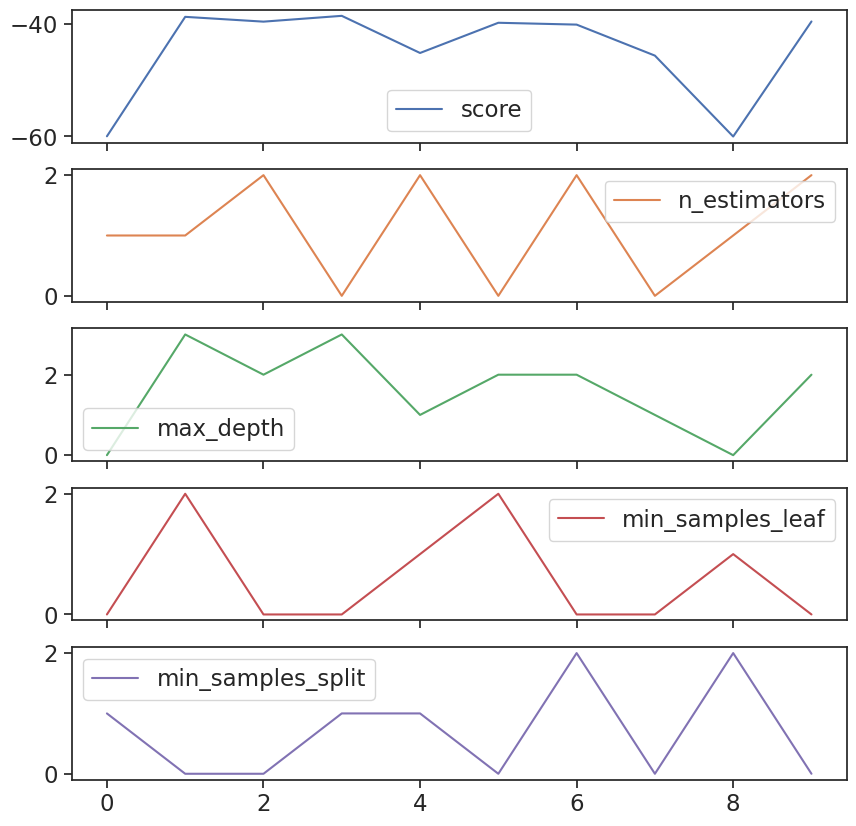

In [655]:
tpe_results=np.array([[x['result']['loss'],
                      x['misc']['vals']['n_estimators'][0],
                      x['misc']['vals']['max_depth'][0],
                      x['misc']['vals']['min_samples_leaf'][0],
                      x['misc']['vals']['min_samples_split'][0]] for x in trial.trials])

tpe_results_df=pd.DataFrame(tpe_results,
                           columns=['score', 'n_estimators', 'max_depth', 'min_samples_leaf', 'min_samples_split'])

tpe_results_df.plot(subplots=True, figsize=(10, 10))

{'max_depth': 0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 1}

## Code dump

In [553]:
parameters = {'n_estimators':[100, 500, 1000], 'learning_rate':[0.01, 0.1, 1]}
# reg = RandomForestRegressor(n_jobs=16)
reg = GradientBoostingRegressor()
clf = GridSearchCV(reg, parameters, scoring='neg_root_mean_squared_error')
clf.fit(X=metrics_df[metrics_to_plot + additional_metrics].values, y=metrics_df['temp'])

GridSearchCV(estimator=GradientBoostingRegressor(),
             param_grid={'learning_rate': [0.01, 0.1, 1],
                         'n_estimators': [100, 500, 1000]},
             scoring='neg_root_mean_squared_error')

In [554]:
def plot_grid_search(cv_results, grid_param_1, grid_param_2, name_param_1, name_param_2):
    # Get Test Scores Mean and std for each grid search
    scores_mean = cv_results['mean_test_score']
    scores_mean = np.array(scores_mean).reshape(len(grid_param_2),len(grid_param_1))

    scores_sd = cv_results['std_test_score']
    scores_sd = np.array(scores_sd).reshape(len(grid_param_2),len(grid_param_1))

    # Plot Grid search scores
    _, ax = plt.subplots(1,1)

    # Param1 is the X-axis, Param 2 is represented as a different curve (color line)
    for idx, val in enumerate(grid_param_2):
        ax.plot(grid_param_1, scores_mean[idx,:], '-o', label= name_param_2 + ': ' + str(val))

    ax.set_title("Grid Search Scores", fontsize=20, fontweight='bold')
    ax.set_xlabel(name_param_1, fontsize=16)
    ax.set_ylabel('CV Average Score', fontsize=16)
    ax.legend(loc="best", fontsize=15)
    ax.grid('on')



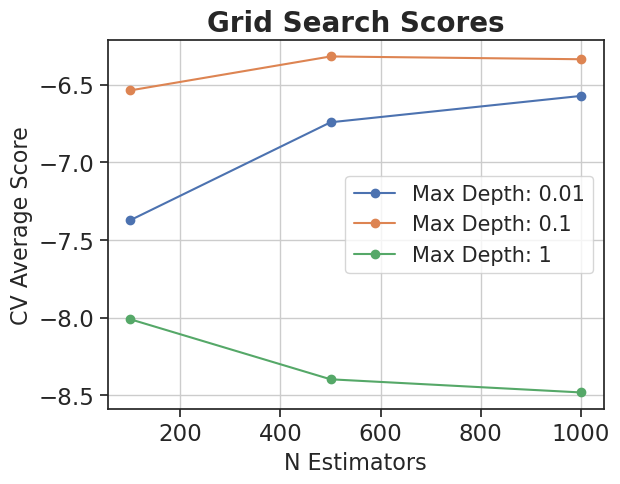

In [555]:
# Calling Method 
plot_grid_search(clf.cv_results_, parameters['n_estimators'], parameters['learning_rate'], 'N Estimators', 'Max Depth')

In [560]:
reg = GradientBoostingRegressor(n_estimators=500)
reg.fit(X=metrics_df[metrics_to_plot + additional_metrics].values, y=metrics_df['temp'])

AttributeError: 'function' object has no attribute 'fit'

Text(0.5, 1.0, 'Regressor Performance')

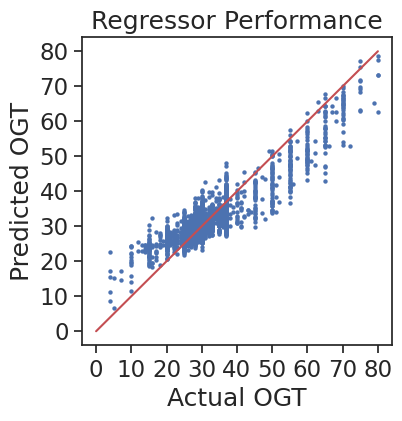

In [559]:
fig, ax = plt.subplots(figsize=(4, 4))
sns.scatterplot(x=metrics_df['temp'], y=clf.best_estimator_.predict(metrics_df[metrics_to_plot + additional_metrics].values), linewidth=0, alpha=1, s=10)
plt.plot((0, 80), (0, 80), color='r')
yticks = ax.set_yticks(list(np.linspace(0, 80, 9)))
xticks = ax.set_xticks(list(np.linspace(0, 80, 9)))
ax.set_xlabel('Actual OGT')
ax.set_ylabel('Predicted OGT')
ax.set_title('Regressor Performance')

In [821]:
spearmanr(metrics_df['temp'], clf.best_estimator_.predict(metrics_df[metrics_to_plot + additional_metrics].values))

SignificanceResult(statistic=0.7400537865984281, pvalue=0.0)

## check density of 37 degree points

In [836]:
corkey = pd.read_csv('/data/mhoffert/fiererlab/ogt/source_data/Corkey_temperatures.csv')
corkey['genus'] = corkey['binomial.name'].apply(lambda x: x.split(' ')[0].lower())
corkey['species'] = corkey['binomial.name'].apply(lambda x: x.split(' ')[1].lower())
corkey.head()

,strain.code,T.C,rate.per.minute,domain,kingdom,phylum,binomial.name,aero,trophy,genus,species
0,1,37.0,0.070729,Bacteria,Bacteria,Proteobacteria,Vibrio natriegens,FA,H,vibrio,natriegens
1,2,65.0,0.002310,Bacteria,Bacteria,Firmicutes,Desulfotomaculum sp.,AN,A,desulfotomaculum,sp.
2,3,28.0,0.001332,Bacteria,Bacteria,Firmicutes,Geobacillus sp.,FA,H,geobacillus,sp.
3,3,35.0,0.003633,Bacteria,Bacteria,Firmicutes,Geobacillus sp.,FA,H,geobacillus,sp.
4,3,40.0,0.004650,Bacteria,Bacteria,Firmicutes,Geobacillus sp.,FA,H,geobacillus,sp.


In [841]:
len(corkey['binomial.name'].unique())

978

In [837]:
base_path = '/data/mhoffert/fiererlab/ogt/results/db/'
corkey_match = pd.read_csv(f'{base_path}corkey_gtdb_matching.tsv', sep='\t')

In [846]:
corkey_data = pd.merge(corkey, corkey_match[corkey_match['match_accession'].isin(metrics_df.genome)], left_on='binomial.name', right_on='original_id', how='right')

In [851]:
corkey[corkey['binomial.name'].eq('Acaryochloris marina')]

,strain.code,T.C,rate.per.minute,domain,kingdom,phylum,binomial.name,aero,trophy,genus,species
8757,1249,14.966516,0.000020,Bacteria,Bacteria,Cyanobacteria,Acaryochloris marina,A,A,acaryochloris,marina
8758,1249,19.988769,0.000192,Bacteria,Bacteria,Cyanobacteria,Acaryochloris marina,A,A,acaryochloris,marina
8759,1249,24.669116,0.000330,Bacteria,Bacteria,Cyanobacteria,Acaryochloris marina,A,A,acaryochloris,marina
8760,1249,29.806447,0.000369,Bacteria,Bacteria,Cyanobacteria,Acaryochloris marina,A,A,acaryochloris,marina
8761,1249,34.960693,0.000326,Bacteria,Bacteria,Cyanobacteria,Acaryochloris marina,A,A,acaryochloris,marina
8762,1249,40.064333,0.000109,Bacteria,Bacteria,Cyanobacteria,Acaryochloris marina,A,A,acaryochloris,marina


In [859]:
corkey_data.groupby('match_accession').mean(numeric_only=True)['T.C']

match_accession
GB_GCA_003148465.1    56.500000
RS_GCF_000006985.1    43.032331
RS_GCF_000007925.1    18.294701
RS_GCF_000010305.1    30.000000
RS_GCF_000012325.1     9.689690
                        ...    
RS_GCF_004216575.1    27.691363
RS_GCF_004319545.1    30.500000
RS_GCF_004337705.1    49.605819
RS_GCF_004342625.1    44.943216
RS_GCF_004346265.1    40.112400
Name: T.C, Length: 181, dtype: float64

In [860]:
metrics_df['temp']

0       30.0
1       37.0
2       30.0
3       37.0
4       37.0
        ... 
5224    29.0
5225    30.0
5226    37.0
5227    25.0
5228    28.0
Name: temp, Length: 5229, dtype: float64

<Axes: xlabel='T.C', ylabel='temp'>

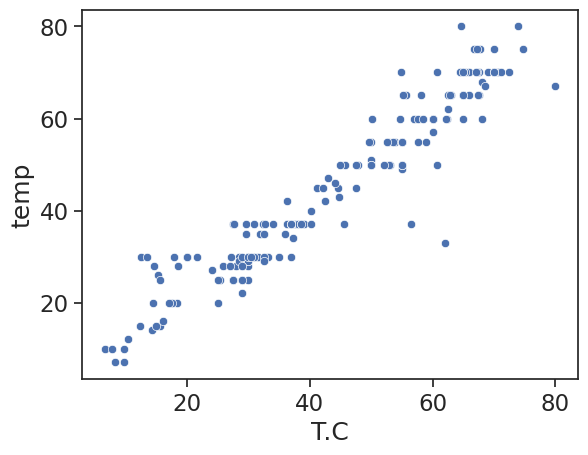

In [861]:
sns.scatterplot(x=corkey_data.groupby('match_accession').mean(numeric_only=True)['T.C'], y=metrics_df.set_index('genome')['temp'])

In [862]:
enqvist_match = pd.read_csv(f'{base_path}engqvist_gtdb_matching.tsv', sep='\t')

In [853]:
corkey_data

,strain.code,T.C,rate.per.minute,domain,kingdom,phylum,binomial.name,aero,trophy,genus,species,Unnamed: 0,original_id,orginal_genus,original_species,match_ratio,match_accession,match_genus,match_species
0,1249,14.966516,0.000020,Bacteria,Bacteria,Cyanobacteria,Acaryochloris marina,A,A,acaryochloris,marina,0,Acaryochloris marina,acaryochloris,marina,100.000000,RS_GCF_000018105.1,acaryochloris,marina
1,1249,19.988769,0.000192,Bacteria,Bacteria,Cyanobacteria,Acaryochloris marina,A,A,acaryochloris,marina,0,Acaryochloris marina,acaryochloris,marina,100.000000,RS_GCF_000018105.1,acaryochloris,marina
2,1249,24.669116,0.000330,Bacteria,Bacteria,Cyanobacteria,Acaryochloris marina,A,A,acaryochloris,marina,0,Acaryochloris marina,acaryochloris,marina,100.000000,RS_GCF_000018105.1,acaryochloris,marina
3,1249,29.806447,0.000369,Bacteria,Bacteria,Cyanobacteria,Acaryochloris marina,A,A,acaryochloris,marina,0,Acaryochloris marina,acaryochloris,marina,100.000000,RS_GCF_000018105.1,acaryochloris,marina
4,1249,34.960693,0.000326,Bacteria,Bacteria,Cyanobacteria,Acaryochloris marina,A,A,acaryochloris,marina,0,Acaryochloris marina,acaryochloris,marina,100.000000,RS_GCF_000018105.1,acaryochloris,marina
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1487,202,5.952222,0.000376,Bacteria,Bacteria,Proteobacteria,Vibrio psychroerythrus,FA,H,vibrio,psychroerythrus,537,Vibrio psychroerythrus,vibrio,psychroerythrus,57.142857,RS_GCF_000012325.1,colwellia,psychrerythraea_a
1488,202,7.092058,0.001074,Bacteria,Bacteria,Proteobacteria,Vibrio psychroerythrus,FA,H,vibrio,psychroerythrus,537,Vibrio psychroerythrus,vibrio,psychroerythrus,57.142857,RS_GCF_000012325.1,colwellia,psychrerythraea_a
1489,202,10.025885,0.001453,Bacteria,Bacteria,Proteobacteria,Vibrio psychroerythrus,FA,H,vibrio,psychroerythrus,537,Vibrio psychroerythrus,vibrio,psychroerythrus,57.142857,RS_GCF_000012325.1,colwellia,psychrerythraea_a
1490,202,11.517551,0.001553,Bacteria,Bacteria,Proteobacteria,Vibrio psychroerythrus,FA,H,vibrio,psychroerythrus,537,Vibrio psychroerythrus,vibrio,psychroerythrus,57.142857,RS_GCF_000012325.1,colwellia,psychrerythraea_a
